## Importing Libraries

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Machine Learning Models
from xgboost import XGBRegressor
from sklearn.cluster import KMeans

# Model Evaluation
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score, silhouette_score)

# Visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Data Reading

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
file_path = "online_retail_II.xlsx"

# Check available sheet names
xls = pd.ExcelFile(file_path)
print("Sheet Names:", xls.sheet_names)

# Load both sheets from the same Excel file
sheet1 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
sheet2 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

# Combine both sheets into one master dataframe
df = pd.concat([sheet1, sheet2], ignore_index=True)

# Basic verification
print("Combined Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 Rows:")
print(df.head())

# Save as CSV for future use
df.to_csv("online_retail_combined.csv", index=False)

print("\nCSV file created successfully: online_retail_combined.csv")

Saving online_retail_II.xlsx to online_retail_II (1).xlsx
Sheet Names: ['Year 2009-2010', 'Year 2010-2011']
Combined Shape: (1067371, 8)

Columns:
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      1308

In [ ]:
df=pd.read_csv('/content/online_retail_combined.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## Data Cleaning

In [ ]:
# Here i am Checking Duplicate Values
df.duplicated().sum()
print(f"Duplicate Values: {df.duplicated().sum()}\n")

# Here i am Checking Null Values
print(f"\nNull Values:\n{df.isnull().sum()}")

print("\nShape Before removing missing Customer ID:", df.shape)


Duplicate Values: 34335


Null Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Shape Before removing missing Customer ID: (1067371, 8)


In [ ]:
# I Removed duplicate values
df=df.drop_duplicates()

# I Removed rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])

In [ ]:
# Checking Duplicate Values after removing them
df.duplicated().sum()
print(f"Duplicate Values After Cleaning: {df.duplicated().sum()}\n")

# Checking Null Values after removing them
print(f"\nNull Values After Cleaning:\n{df.isnull().sum()}")

# Checking new shape after cleaning
print("\nShape after removing missing Customer ID:", df.shape)

Duplicate Values After Cleaning: 0


Null Values After Cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Shape after removing missing Customer ID: (797885, 8)


In [ ]:
# Checking cancelled invoices
cancelled_invoices = df['Invoice'].astype(str).str.startswith('C').sum()

# Checking zero or negative quantity
negative_quantity = (df['Quantity'] <= 0).sum()

# Checking zero or negative price
negative_price = (df['Price'] <= 0).sum()

print("Cancelled Invoices:", cancelled_invoices)
print("Zero/Negative Quantity Rows:", negative_quantity)
print("Zero/Negative Price Rows:", negative_price)


Cancelled Invoices: 18390
Zero/Negative Quantity Rows: 18390
Zero/Negative Price Rows: 70


In [ ]:
# Removed cancelled invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Removed zero or negative quantity
df = df[df['Quantity'] > 0]

# Removed zero or negative price
df = df[df['Price'] > 0]


In [ ]:
# Rechecking cancelled invoices,negative quantity and invalid prices after removing the

print("\nCancelled Invoices Remaining:", df['Invoice'].astype(str).str.startswith('C').sum())
print("Negative Quantity Remaining:", (df['Quantity'] <= 0).sum())
print("Invalid Price Remaining:", (df['Price'] <= 0).sum())

# Checking final shape after performing cleaning
print("Final Cleaned Shape:", df.shape)


Cancelled Invoices Remaining: 0
Negative Quantity Remaining: 0
Invalid Price Remaining: 0
Final Cleaned Shape: (779425, 8)


# Feature Engineering

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['Price']

# Converting InvoiceDate to datetime for analysis purpose
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Quick validation
print(df[['Quantity', 'Price', 'TotalPrice', 'InvoiceDate']].head())

# Basic revenue stats
print("\nTotal Revenue:", df['TotalPrice'].sum())
print("Average Transaction Value:", df['TotalPrice'].mean())
print("Unique Customers:", df['Customer ID'].nunique())
print("Unique Invoices:", df['Invoice'].nunique())

   Quantity  Price  TotalPrice         InvoiceDate
0        12   6.95        83.4 2009-12-01 07:45:00
1        12   6.75        81.0 2009-12-01 07:45:00
2        12   6.75        81.0 2009-12-01 07:45:00
3        48   2.10       100.8 2009-12-01 07:45:00
4        24   1.25        30.0 2009-12-01 07:45:00

Total Revenue: 17374804.268000003
Average Transaction Value: 22.29182316194631
Unique Customers: 5878
Unique Invoices: 36969


##Feature Engineering with Temporal Split
 Temporal Split:

We want to predict **future spending** from **past behaviour**,
So we must keep them in separate time windows:

```
Dec 2009 ---------------------|--------------------------- Dec 2011
             PAST             │        FUTURE
        (before Jan 2011)     │   (Jan 2011 onwards)
              ↓               │         ↓
      Build 7 FEATURES        │    Measure CLV TARGET
  "what did they do before?"  │  "how much did they spend after?"
```

I Think Without this split, the model would be **cheating** because it may lead to **data leakage** and makes the model useless in real life.

### The 7 Features We Build

|   | Feature  | What it measures |
|---|--------- |------------------|
| 1 | Recency  | How many days since the customer last bought |
| 2 | Frequency| How many unique orders the customer placed |
| 3 | Monetary | How much the customer spent in total (past only) |
| 4 | ProductDiversity | How many different products the customer bought |
| 5 | AvgPurchaseInterval | Average days between consecutive orders |
| 6 | AvgBasketSize | Average number of items per order |
| 7 | AvgUnitPrice | Average price of items the customer buys |

In [ ]:
# DRAWING A TIME BOUNDARY USING TEMPORAL SPLIT TO PREVENT DATA LEAKAGE
# Everything BEFORE cutoff_date = past (used to build features)
# Everything AFTER  cutoff_date = future (used as CLV target)


cutoff_date = pd.Timestamp('2011-01-01')

df_past   = df[df['InvoiceDate'] <  cutoff_date].copy()   # historical data
df_future = df[df['InvoiceDate'] >= cutoff_date].copy()   # future data


In [ ]:
# Investigating wether it splitted correctly or not
print(f"Past period   : {df_past['InvoiceDate'].min().date()} → {df_past['InvoiceDate'].max().date()}")
print(f"Future period : {df_future['InvoiceDate'].min().date()} → {df_future['InvoiceDate'].max().date()}")
print(f"Customers in past   : {df_past['Customer ID'].nunique():,}")
print(f"Customers in future : {df_future['Customer ID'].nunique():,}")

Past period   : 2009-12-01 → 2010-12-23
Future period : 2011-01-04 → 2011-12-09
Customers in past   : 4,342
Customers in future : 4,219


### Feature Engineering With RFM Metrics

In [ ]:

# STEP 1: SET A REFERENCE DATE FOR RECENCY
# "Today" = 1 day after the last transaction in past data
# Used to calculate how recently each customer bought

reference_date = df_past['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\nReference date for Recency : {reference_date.date()}")



# STEP 2: CALCULATE RFM FEATURES (from past data only)
# Recency   = how many days since last purchase
# Frequency = how many unique orders placed
# Monetary  = total amount spent in the past

rfm = df_past.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"\nRFM table shape : {rfm.shape}")
print(rfm.head(3))


# STEP 3: CALCULATE PRODUCT DIVERSITY (from past data only)
# How many different products did each customer buy?

product_diversity =
 (df_past.groupby('Customer ID')['StockCode'].nunique().reset_index().rename(columns={'StockCode': 'ProductDiversity'}))

print(f"\nProduct Diversity table shape : {product_diversity.shape}")


# STEP 4: CALCULATE AVERAGE PURCHASE INTERVAL (from past data only)
# Average number of days between consecutive orders per customer

def avg_purchase_interval(dates):
    # Get sorted list of unique purchase dates
    sorted_dates = sorted(dates.unique())

    # If only 1 purchase, no interval to calculate → return 0
    if len(sorted_dates) < 2:
        return 0

    # Calculate gap in days between each consecutive pair of dates
    intervals = [
        (sorted_dates[i+1] - sorted_dates[i]).days
        for i in range(len(sorted_dates) - 1)
    ]

    # Return the average gap
    return np.mean(intervals)

purchase_interval =
 (df_past.groupby('Customer ID')['InvoiceDate'].apply(avg_purchase_interval).reset_index().rename(columns={'InvoiceDate': 'AvgPurchaseInterval'}))

print(f"Purchase Interval table shape : {purchase_interval.shape}")



# STEP 5: CALCULATE AVERAGE BASKET SIZE (from past data only)
# Average total quantity of items per order per customer
# Two-step: first sum per order, then average across orders

# Step 5a: Total items per order (per customer + invoice)
items_per_order = (df_past.groupby(['Customer ID', 'Invoice'])['Quantity'].sum().reset_index())

# Step 5b: Average of those order totals per customer
basket_size = (items_per_order.groupby('Customer ID')['Quantity'].mean().reset_index().rename(columns={'Quantity': 'AvgBasketSize'}))

print(f"Basket Size table shape : {basket_size.shape}")



# STEP 6: CALCULATE AVERAGE UNIT PRICE (from past data only)
# Average price of items each customer tends to buy
# Captures whether they are a premium or budget buyer

avg_unit_price = (df_past .groupby('Customer ID')['Price'] .mean() .reset_index() .rename(columns={'Price': 'AvgUnitPrice'}))

print(f"Avg Unit Price table shape : {avg_unit_price.shape}")



# STEP 7: CALCULATE CLV TARGET (from FUTURE data only)
# This is what we want to predict — real future spending
# Kept completely separate from all features above

clv_target = ( df_future .groupby('Customer ID')['TotalPrice'] .sum() .reset_index() .rename(columns={'TotalPrice': 'CLV'}))

print(f"\nCLV target table shape : {clv_target.shape}")
print(f"Average future CLV : £{clv_target['CLV'].mean():,.2f}")



# STEP 8: COMBINE ALL FEATURES INTO ONE TABLE
# Start with RFM, then left-merge each extra feature
# left merge = keep all customers even if a feature is missing

customer_df = rfm.copy()

for extra_feature in [product_diversity, purchase_interval, basket_size, avg_unit_price]:
    customer_df = customer_df.merge(extra_feature, on='Customer ID', how='left')

# Fill any missing values with 0
# (e.g. a customer who only bought once has no purchase interval)
customer_df.fillna(0, inplace=True)

print(f"\nFeature table shape after merging : {customer_df.shape}")



# STEP 9: ADD THE CLV TARGET TO THE FEATURE TABLE
# inner merge = keep only customers who appear in BOTH periods
# Customers who never returned after cutoff are excluded

customer_df = customer_df.merge(clv_target, on='Customer ID', how='inner')

print(f"Final table shape (both periods) : {customer_df.shape}")
print(f"Customers with CLV = 0 (churned) : {(customer_df['CLV'] == 0).sum():,}")



# STEP 10: LOG-TRANSFORM THE CLV
# Raw CLV is very skewed (most customers low, a few very high)
# log1p compresses the scale so the model learns better
# log1p(x) = log(1 + x) - handles 0 values safely


customer_df['CLV_log'] = np.log1p(customer_df['CLV'])

print(f"\nCLV range (raw)  : £{customer_df['CLV'].min():.2f} → £{customer_df['CLV'].max():,.2f}")
print(f"CLV range (log)    : {customer_df['CLV_log'].min():.2f} → {customer_df['CLV_log'].max():.2f}")



# FINAL CHECK AFTER COMPLETING FEATURE ENGINEERING

print(f"\n Feature engineering complete!")
print(f"   Total customers : {len(customer_df):,}")
print(f"   Columns         : {customer_df.columns.tolist()}")
customer_df.head()


Reference date for Recency : 2010-12-24

RFM table shape : (4342, 4)
   Customer ID  Recency  Frequency  Monetary
0      12346.0      179         11    372.86
1      12347.0       17          2   1323.32
2      12348.0        7          2   1114.96

Product Diversity table shape : (4342, 2)
Purchase Interval table shape : (4342, 2)
Basket Size table shape : (4342, 2)
Avg Unit Price table shape : (4342, 2)

CLV target table shape : (4219, 2)
Average future CLV : £1,971.27

Feature table shape after merging : (4342, 8)
Final table shape (both periods) : (2683, 9)
Customers with CLV = 0 (churned) : 0

CLV range (raw)        : £6.90 → £271,614.14
CLV range (log)        : 2.07 → 12.51

 Feature engineering complete!
   Total customers : 2,683
   Columns         : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'ProductDiversity', 'AvgPurchaseInterval', 'AvgBasketSize', 'AvgUnitPrice', 'CLV', 'CLV_log']


,Customer ID,Recency,Frequency,Monetary,ProductDiversity,AvgPurchaseInterval,AvgBasketSize,AvgUnitPrice,CLV,CLV_log
0,12346.0,179,11,372.86,26,19.2,6.363636,6.253333,77183.60,11.253955
1,12347.0,17,2,1323.32,70,37.0,414.000000,2.295070,3598.21,8.188470
2,12348.0,7,2,1114.96,21,80.0,813.500000,1.729459,904.44,6.808421
3,12349.0,57,3,2671.14,90,90.0,331.000000,8.581765,1757.55,7.472245
4,12352.0,25,2,343.80,18,16.0,94.000000,3.033333,2506.04,7.826858


In [ ]:
customer_df.tail()

,Customer ID,Recency,Frequency,Monetary,ProductDiversity,AvgPurchaseInterval,AvgBasketSize,AvgUnitPrice,CLV,CLV_log
2678,18278.0,54,1,240.30,15,0.000000,74.000000,4.363333,173.90,5.164214
2679,18280.0,44,1,307.55,20,0.000000,149.000000,3.550000,180.60,5.201806
2680,18281.0,227,1,120.32,10,0.000000,92.000000,1.901000,80.82,4.404522
2681,18283.0,32,6,619.37,158,54.600000,53.666667,2.199401,2045.53,7.623901
2682,18287.0,32,4,2345.71,77,62.666667,356.750000,2.844588,1837.28,7.516586


## Feature Selection

In [ ]:
# FEATURE SELECTION
feature_cols = ['Recency', 'Frequency', 'Monetary',
                'ProductDiversity', 'AvgPurchaseInterval',
                'AvgBasketSize', 'AvgUnitPrice']

# TARGET VARIABLE: CLV_log (log of future spending - best practice for skewed regression)
target_col = 'CLV_log'

X = customer_df[feature_cols]
y = customer_df[target_col]


# Correlation

Correlation between Monetary and Future CLV: 0.87
0.8689239476681928


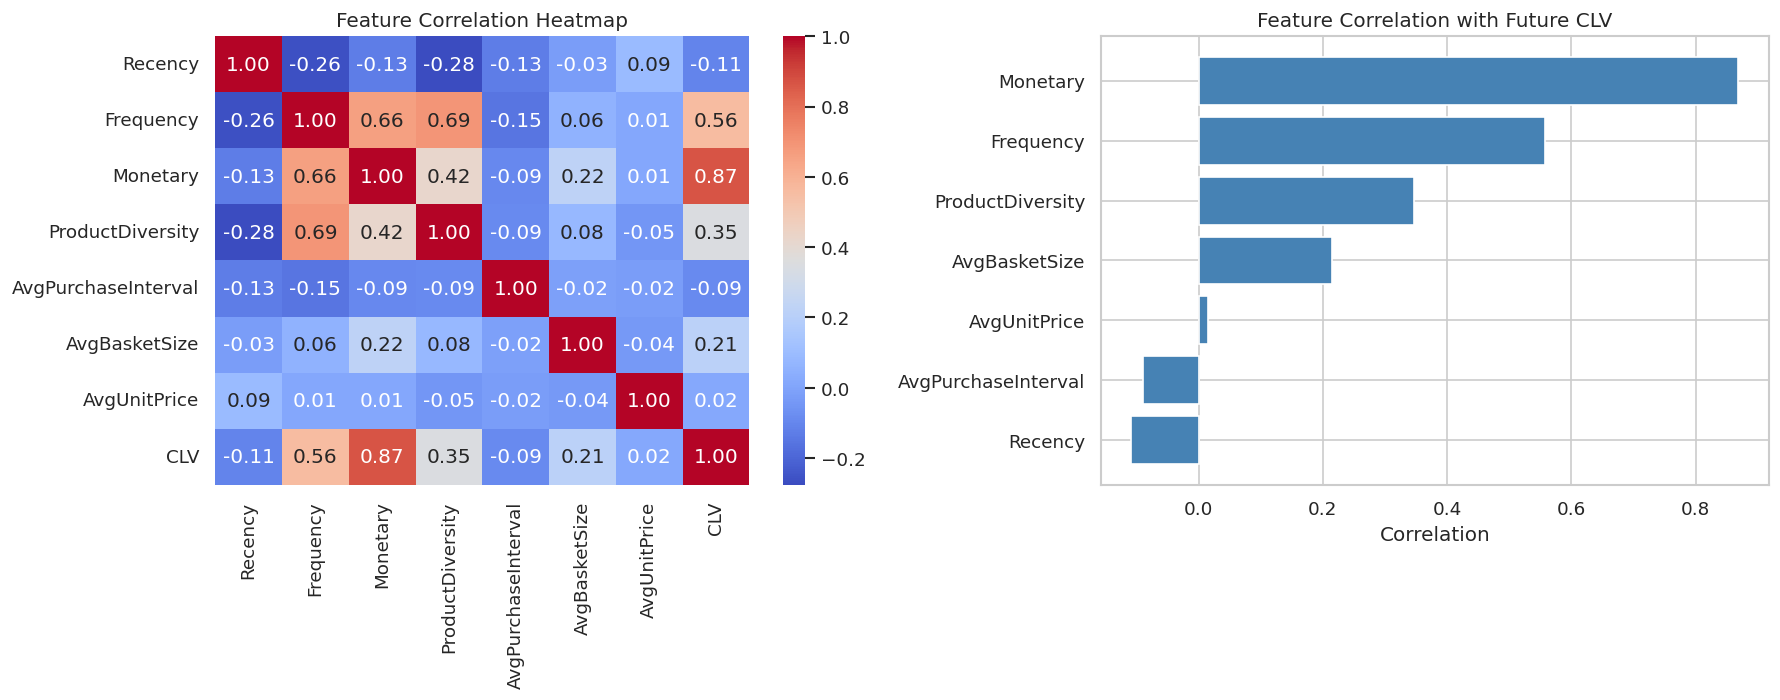

Correlation analysis completed.


In [ ]:
# Correlation Analysis

# Check correlation between past Monetary value and future CLV
corr_value = customer_df["Monetary"].corr(customer_df["CLV"])
print(f"Correlation between Monetary and Future CLV: {corr_value:.2f}")
print(corr_value)

# Calculate correlation matrix
corr = customer_df[feature_cols + ["CLV"]].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",ax=axes[0])

axes[0].set_title("Feature Correlation Heatmap")


# Correlation with CLV

clv_corr = corr["CLV"].drop("CLV").sort_values()

axes[1].barh(clv_corr.index,clv_corr.values,color="steelblue")

axes[1].set_title("Feature Correlation with Future CLV")
axes[1].set_xlabel("Correlation")

plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=300)
plt.show()

print("Correlation analysis completed.")

# Feature Distributions

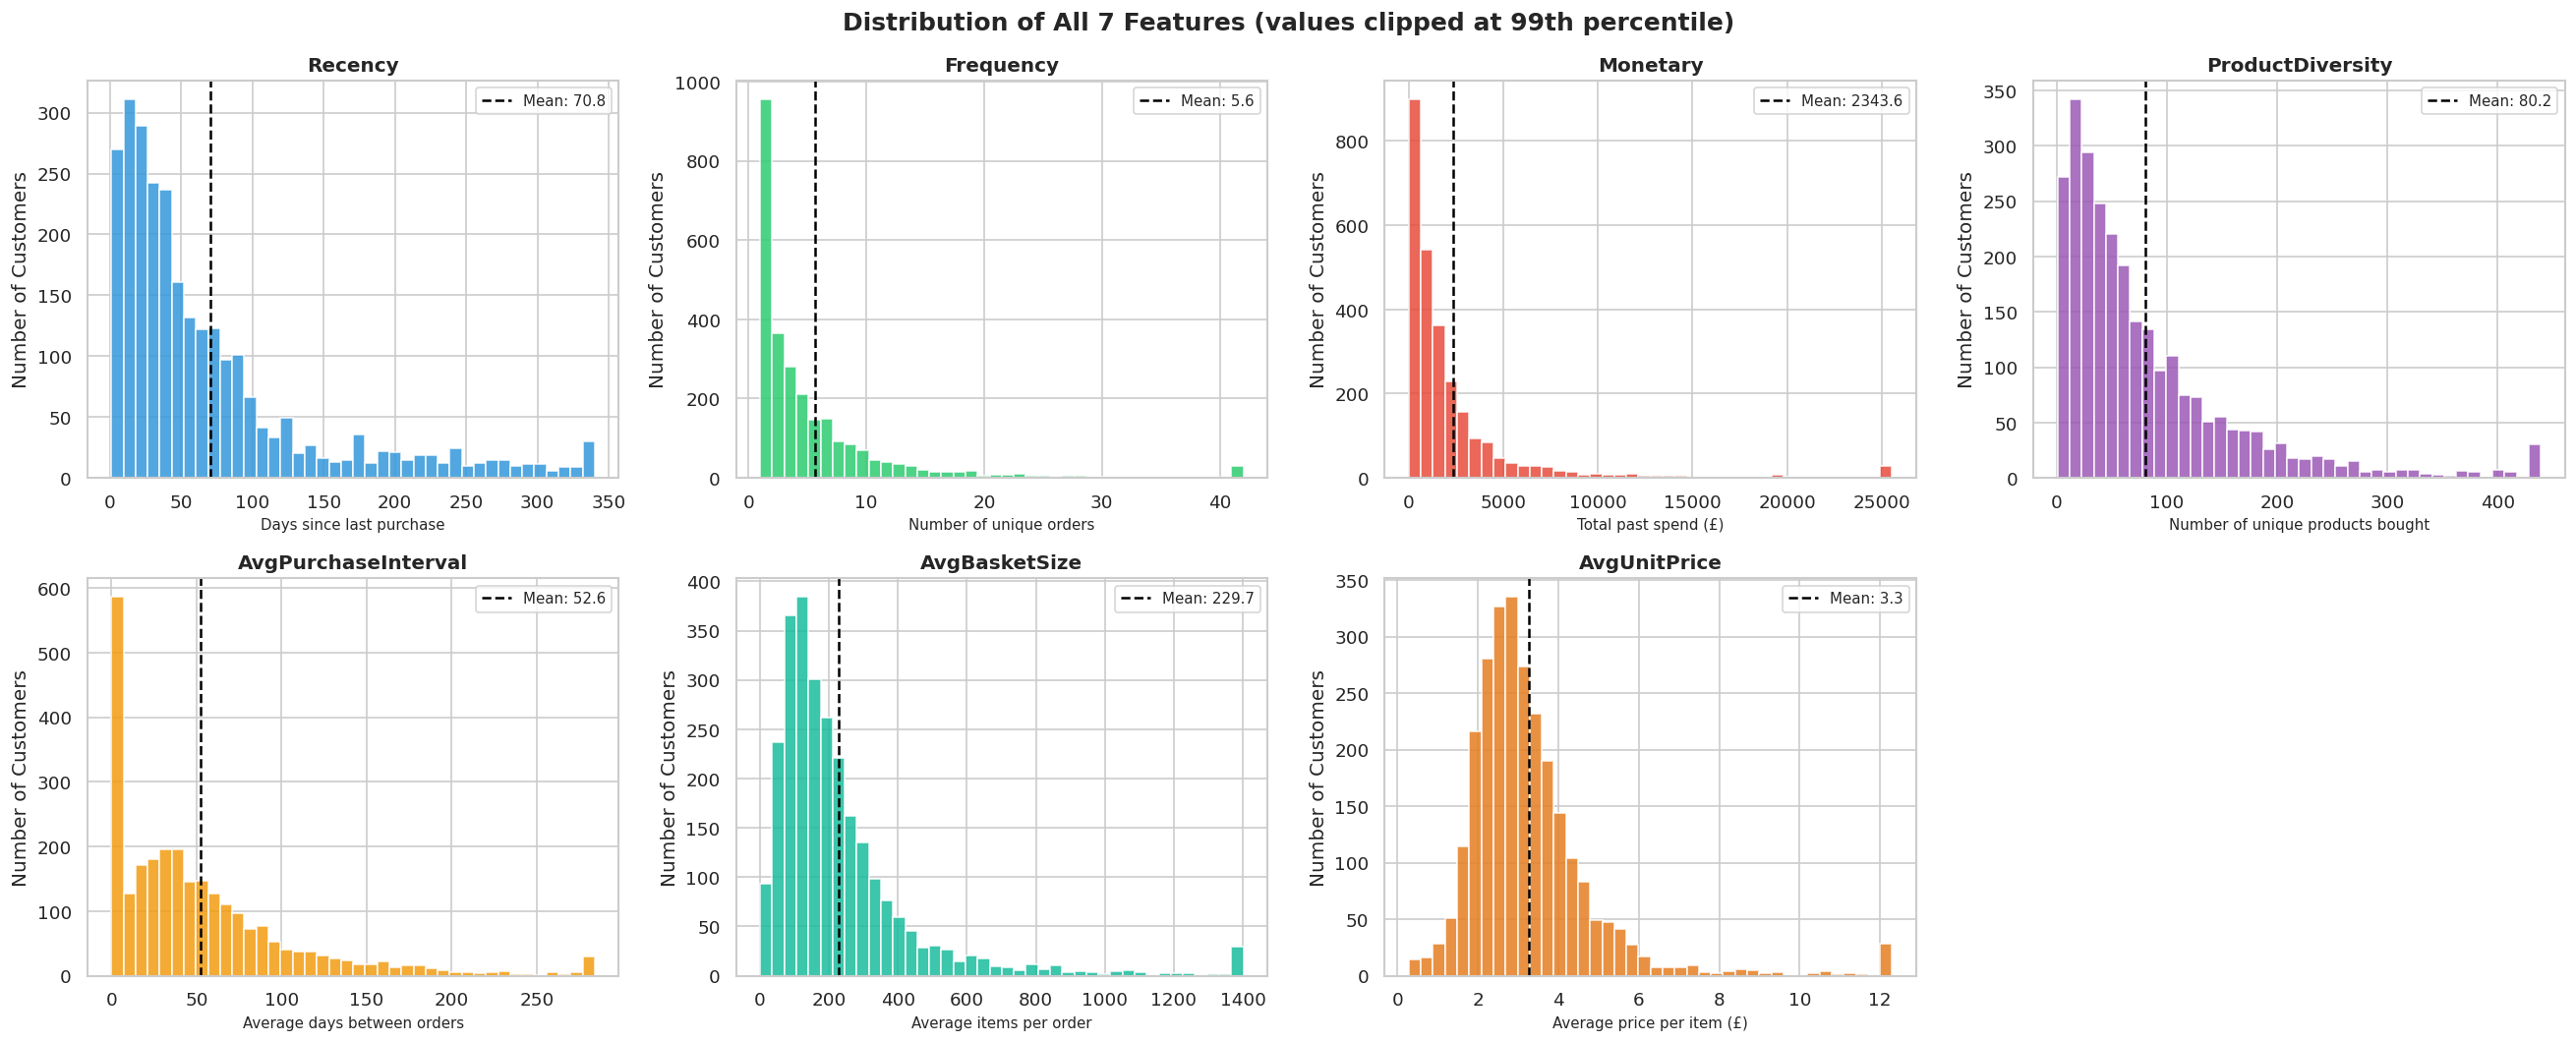

Feature distributions plotted!


In [ ]:
#  We plot all 7 features in one combined view.
#  This helps us understand the shape and spread of each feature
#  before we feed them into the machine learning model.
#
#  Key choices:
#       Clipped at 99th percentile: so 1 extreme customer doesn't stretch the chart and hide the rest
#       Dashed vertical line: shows the mean (average) value
#       40 bins: enough detail without being too noisy


# Set up a 2x4 grid (8 subplots — we'll hide the 8th since we have 7 features)
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle(
    'Distribution of All 7 Features (values clipped at 99th percentile)',
    fontsize=15, fontweight='bold'
)

# Define the features, colours, and x-axis labels for each chart
features = [
    'Recency', 'Frequency', 'Monetary', 'ProductDiversity',
    'AvgPurchaseInterval', 'AvgBasketSize', 'AvgUnitPrice'
]
colors = [
    '#3498db',  # blue   → Recency
    '#2ecc71',  # green  → Frequency
    '#e74c3c',  # red    → Monetary
    '#9b59b6',  # purple → ProductDiversity
    '#f39c12',  # orange → AvgPurchaseInterval
    '#1abc9c',  # teal   → AvgBasketSize
    '#e67e22'   # dark orange → AvgUnitPrice
]
xlabels = [
    'Days since last purchase',
    'Number of unique orders',
    'Total past spend (£)',
    'Number of unique products bought',
    'Average days between orders',
    'Average items per order',
    'Average price per item (£)'
]

# Loop through each feature and draw its histogram
for ax, feat, color, xlabel in zip(axes.flatten(), features, colors, xlabels):

    # Clip at 99th percentile to remove extreme outlier distortion
    data = customer_df[feat].clip(upper=customer_df[feat].quantile(0.99))

    # Draw the histogram
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)

    # Draw a dashed vertical line at the mean so we can see the average
    mean_val = data.mean()
    ax.axvline(
        mean_val, color='black', linestyle='--', linewidth=1.5,
        label=f'Mean: {mean_val:.1f}'
    )

    # Labels and formatting for each subplot
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Number of Customers')
    ax.legend(fontsize=9)

# Hide the empty 8th subplot (we only have 7 features, not 8)
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Feature distributions plotted!')

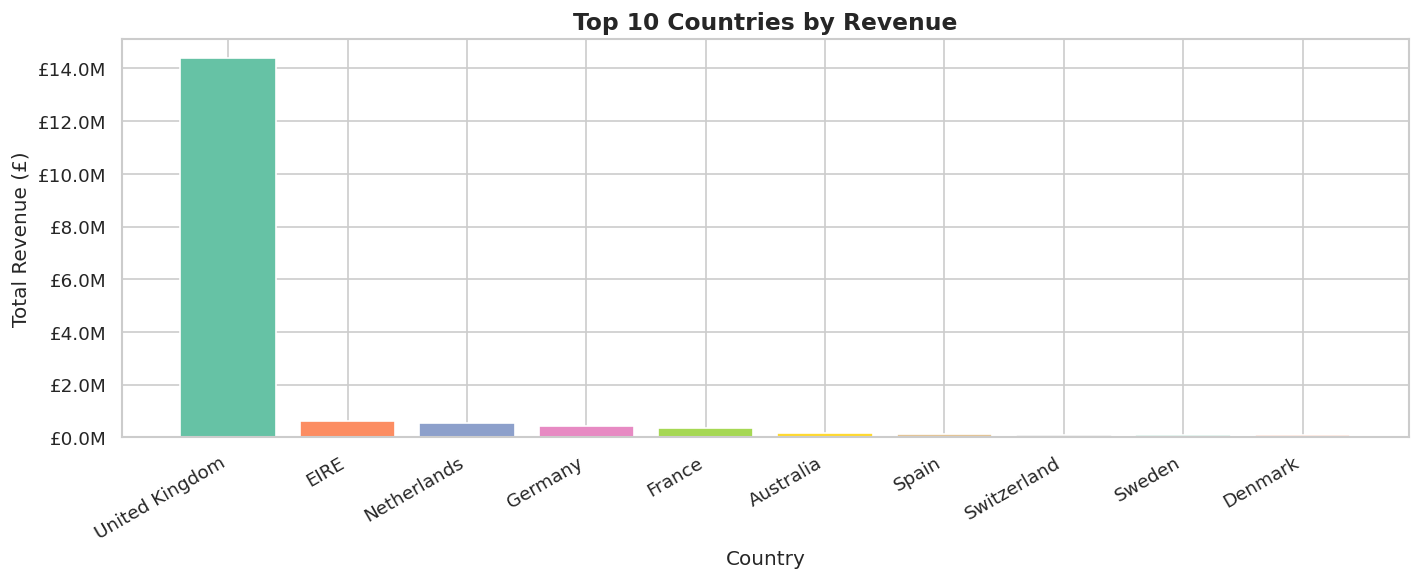

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

top_countries = (df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,5))

plt.bar(top_countries.index,top_countries.values,color=sns.color_palette('Set2', 10))

plt.title('Top 10 Countries by Revenue',fontsize=14,fontweight='bold')

plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Data Splitting

In [ ]:
# TRAIN/TEST SPLIT & SCALING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


print(f"Data split and scaled!")
print(f"  Training samples : {X_train.shape[0]:,}")
print(f"  Testing samples  : {X_test.shape[0]:,}")
print(f"  Features         : {X_train.shape[1]}")

Data split and scaled!
  Training samples : 1,878
  Testing samples  : 805
  Features         : 7


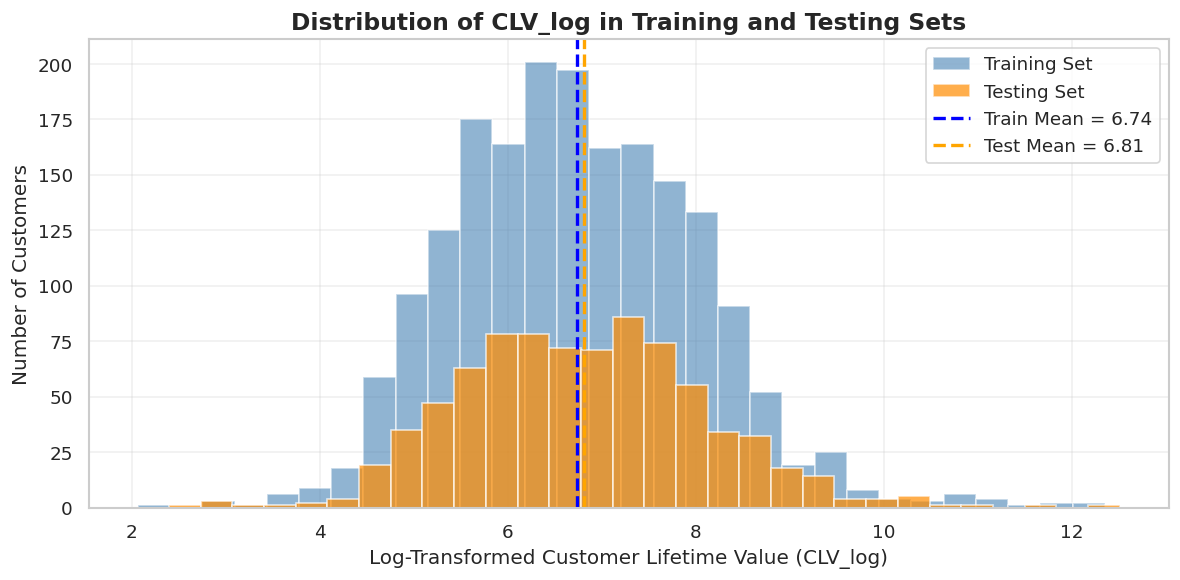

In [ ]:
# Distribution of CLV_log in Training and Testing Sets

plt.figure(figsize=(10, 5))

plt.hist(y_train,bins=30,alpha=0.6,label="Training Set",color="steelblue",edgecolor="white")

plt.hist(y_test,bins=30,alpha=0.7,label="Testing Set",color="darkorange",edgecolor="white")

# Mean lines
plt.axvline(y_train.mean(),color="blue",linestyle="--",linewidth=2,label=f"Train Mean = {y_train.mean():.2f}")

plt.axvline(y_test.mean(),color="orange",linestyle="--",linewidth=2,label=f"Test Mean = {y_test.mean():.2f}")

plt.title("Distribution of CLV_log in Training and Testing Sets",fontsize=14,fontweight="bold")

plt.xlabel("Log-Transformed Customer Lifetime Value (CLV_log)")
plt.ylabel("Number of Customers")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("train_test_distribution.png", dpi=300)

plt.show()

# Machine Learning Models

## XG-Boost Regressor Model-Building

In [ ]:
from xgboost import callback as xgb_callback

xgb_model = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda         = 1.0,
    random_state      = 42,
    eval_metric       = 'rmse',
    verbosity         = 0
)

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

xgb_model.fit( X_train_scaled, y_train, eval_set=eval_set, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

## XG-Boost Regressor Model-Evaluation

In [ ]:
# Evaluation
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb  = xgb_model.predict(X_test_scaled)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
xgb_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred_xgb))
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print("XGBoost CLV Prediction — Evaluation Metrics")
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {xgb_train_rmse:>10.4f} {xgb_test_rmse:>10.4f}")
print(f"{'MAE':<20} {xgb_train_mae:>10.4f} {xgb_test_mae:>10.4f}")
print(f"{'R² Score':<20} {xgb_train_r2:>10.4f} {xgb_test_r2:>10.4f}")

# 5-Fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(
    XGBRegressor(n_estimators=300, learning_rate=0.05,
                 max_depth=6, random_state=42, verbosity=0),
    X_train_scaled, y_train, cv=kfold, scoring='r2'
)
print(f"\n5-Fold CV R²: Mean={cv_scores_xgb.mean():.4f}  Std={cv_scores_xgb.std():.4f}")

XGBoost CLV Prediction — Evaluation Metrics
Metric                    Train       Test
------------------------------------------
RMSE                     0.3442     0.9333
MAE                      0.2652     0.7054
R² Score                 0.9282     0.4777

5-Fold CV R²: Mean=0.4756  Std=0.0839


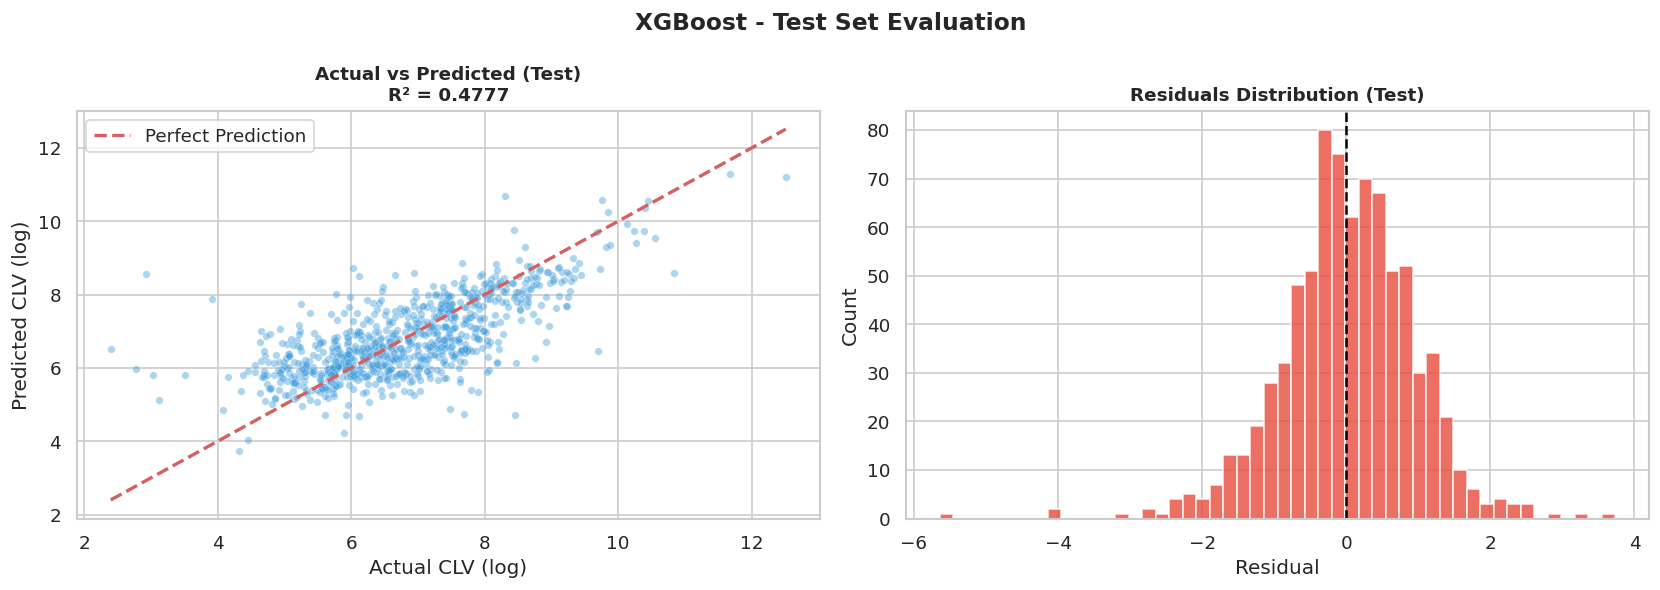

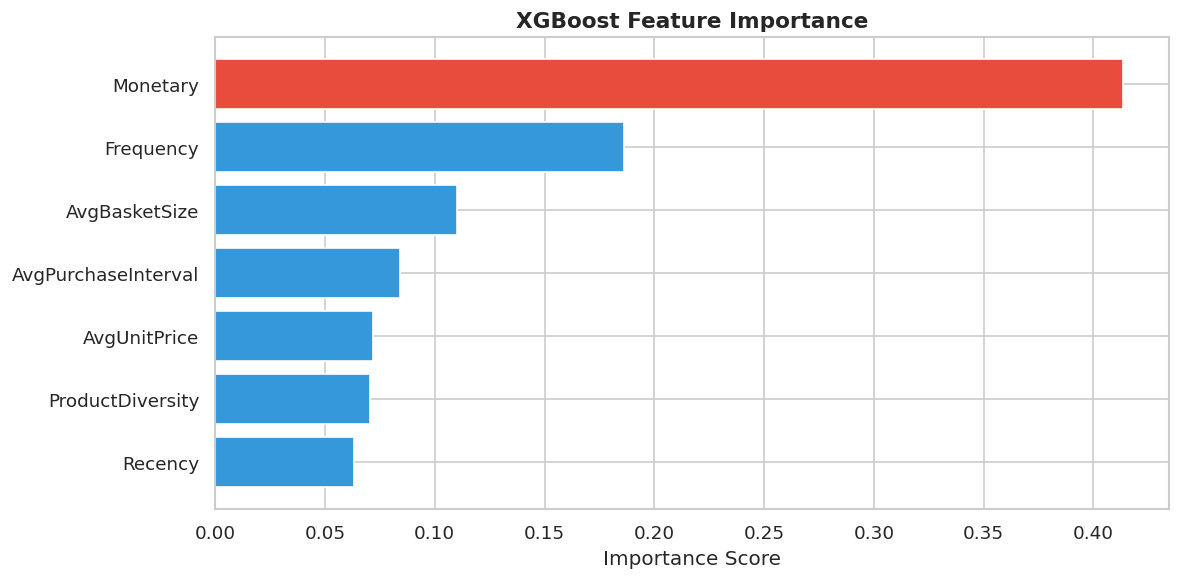

XGBoost complete!


In [ ]:
# Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost - Test Set Evaluation', fontsize=14, fontweight='bold')

axes[0].scatter(y_test, y_test_pred_xgb, alpha=0.4, color='#3498db', s=20, edgecolors='white', linewidth=0.3)
min_v, max_v = min(y_test.min(), y_test_pred_xgb.min()), max(y_test.max(), y_test_pred_xgb.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted (Test)\nR² = {xgb_test_r2:.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Actual CLV (log)'); axes[0].set_ylabel('Predicted CLV (log)'); axes[0].legend()

residuals_xgb = np.array(y_test) - y_test_pred_xgb
axes[1].hist(residuals_xgb, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution (Test)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('xgb_evaluation.png', bbox_inches='tight')
plt.show()

# Feature Importance
feat_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = ['#e74c3c' if v == feat_importance.max() else '#3498db' for v in feat_importance.values]
ax.barh(feat_importance.index, feat_importance.values, color=colors_fi, edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight')
plt.show()
print("XGBoost complete!")

# Implementing Another ML model for comparision

## Light GBM Regressor-Building

In [ ]:
# MODEL 2: LightGBM CLV Prediction
import lightgbm as lgb

# Validation split from training set for LightGBM early stopping
X_lgb_train, X_lgb_val, y_lgb_train, y_lgb_val = train_test_split(
    X_train_scaled, y_train, test_size=0.10, random_state=42
)

print(f"LightGBM splits:")
print(f"  Train : {X_lgb_train.shape}")
print(f"  Val   : {X_lgb_val.shape}")
print(f"  Test  : {X_test_scaled.shape}")

lgb_model = lgb.LGBMRegressor(
    n_estimators       = 500,
    learning_rate      = 0.05,
    max_depth          = 6,
    num_leaves         = 31,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    random_state       = 42,
    verbose            = -1
)

lgb_model.fit(
    X_lgb_train, y_lgb_train,
    eval_set=[(X_lgb_train, y_lgb_train), (X_lgb_val, y_lgb_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

print(f"\nLightGBM training complete!")
print(f"  Best iteration : {lgb_model.best_iteration_}")


LightGBM splits:
  Train : (1690, 7)
  Val   : (188, 7)
  Test  : (805, 7)

LightGBM training complete!
  Best iteration : 73


## Light GBM Regressor-Evaluation

LightGBM CLV Prediction — Evaluation Metrics
Metric                    Train       Test
------------------------------------------
RMSE                     0.7271     0.8955
MAE                      0.5634     0.6848
R² Score                 0.6798     0.5191

5-Fold CV R²: Mean=0.4894  Std=0.0695


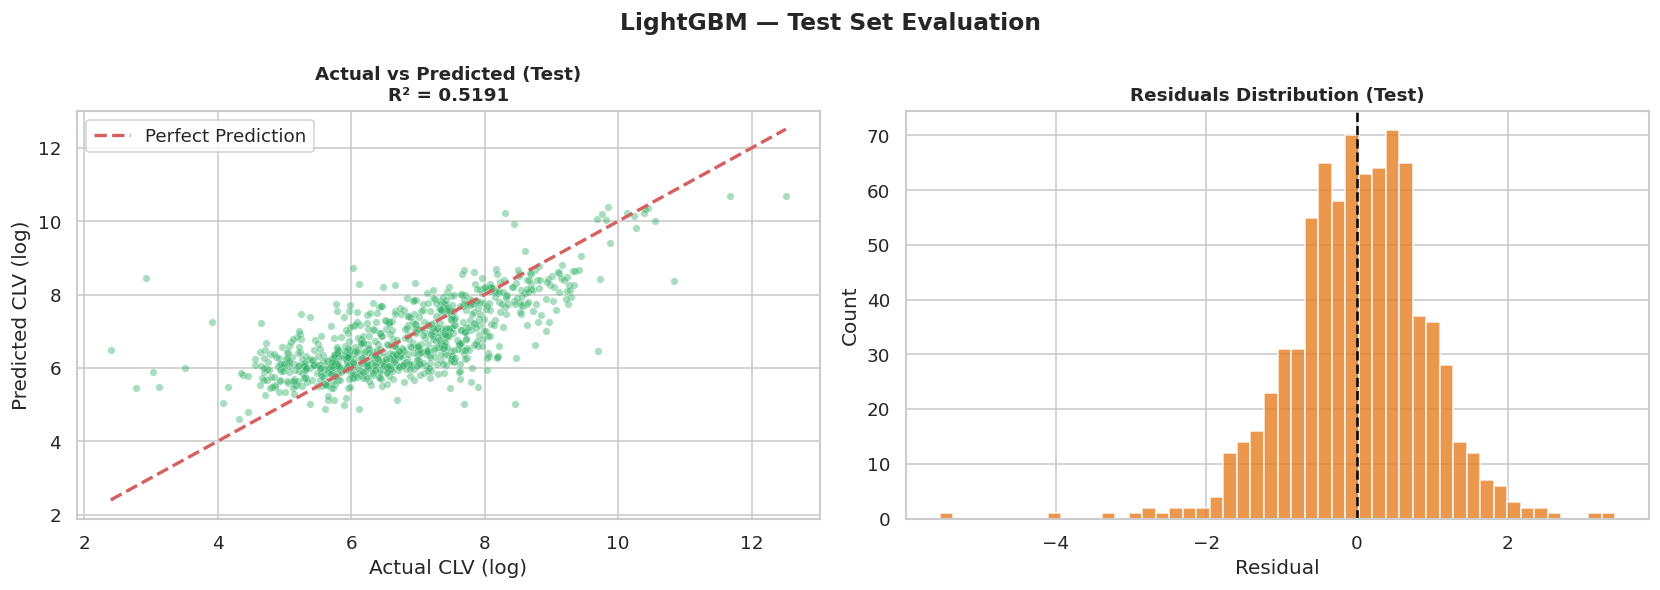

LightGBM complete!


In [ ]:
# Evaluation
y_train_pred_lgb = lgb_model.predict(X_train_scaled)
y_test_pred_lgb  = lgb_model.predict(X_test_scaled)

lgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))
lgb_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred_lgb))
lgb_train_mae  = mean_absolute_error(y_train, y_train_pred_lgb)
lgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_lgb)
lgb_train_r2   = r2_score(y_train, y_train_pred_lgb)
lgb_test_r2    = r2_score(y_test,  y_test_pred_lgb)

print("LightGBM CLV Prediction — Evaluation Metrics")
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {lgb_train_rmse:>10.4f} {lgb_test_rmse:>10.4f}")
print(f"{'MAE':<20} {lgb_train_mae:>10.4f} {lgb_test_mae:>10.4f}")
print(f"{'R² Score':<20} {lgb_train_r2:>10.4f} {lgb_test_r2:>10.4f}")

# 5-Fold CV
cv_scores_lgb = cross_val_score(
    lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                      max_depth=6, random_state=42, verbose=-1),
    X_train_scaled, y_train, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2'
)
print(f"\n5-Fold CV R²: Mean={cv_scores_lgb.mean():.4f}  Std={cv_scores_lgb.std():.4f}")

# Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM — Test Set Evaluation', fontsize=14, fontweight='bold')

axes[0].scatter(y_test, y_test_pred_lgb, alpha=0.4, color='#27ae60', s=20, edgecolors='white', linewidth=0.3)
min_v, max_v = min(y_test.min(), y_test_pred_lgb.min()), max(y_test.max(), y_test_pred_lgb.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted (Test)\nR² = {lgb_test_r2:.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Actual CLV (log)'); axes[0].set_ylabel('Predicted CLV (log)'); axes[0].legend()

residuals_lgb = y_test - y_test_pred_lgb
axes[1].hist(residuals_lgb, bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution (Test)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('lgb_evaluation.png', bbox_inches='tight')
plt.show()
print("LightGBM complete!")

# Model Comparision

        FINAL MODEL COMPARISON REPORT
        Target: CLV_log (log of future 2011 spending)

Model                    Train R²    Test R²  Test RMSE   Test MAE
XGBoost                    0.9282     0.4777     0.9333     0.7054
LightGBM                   0.6798     0.5191     0.8955     0.6848


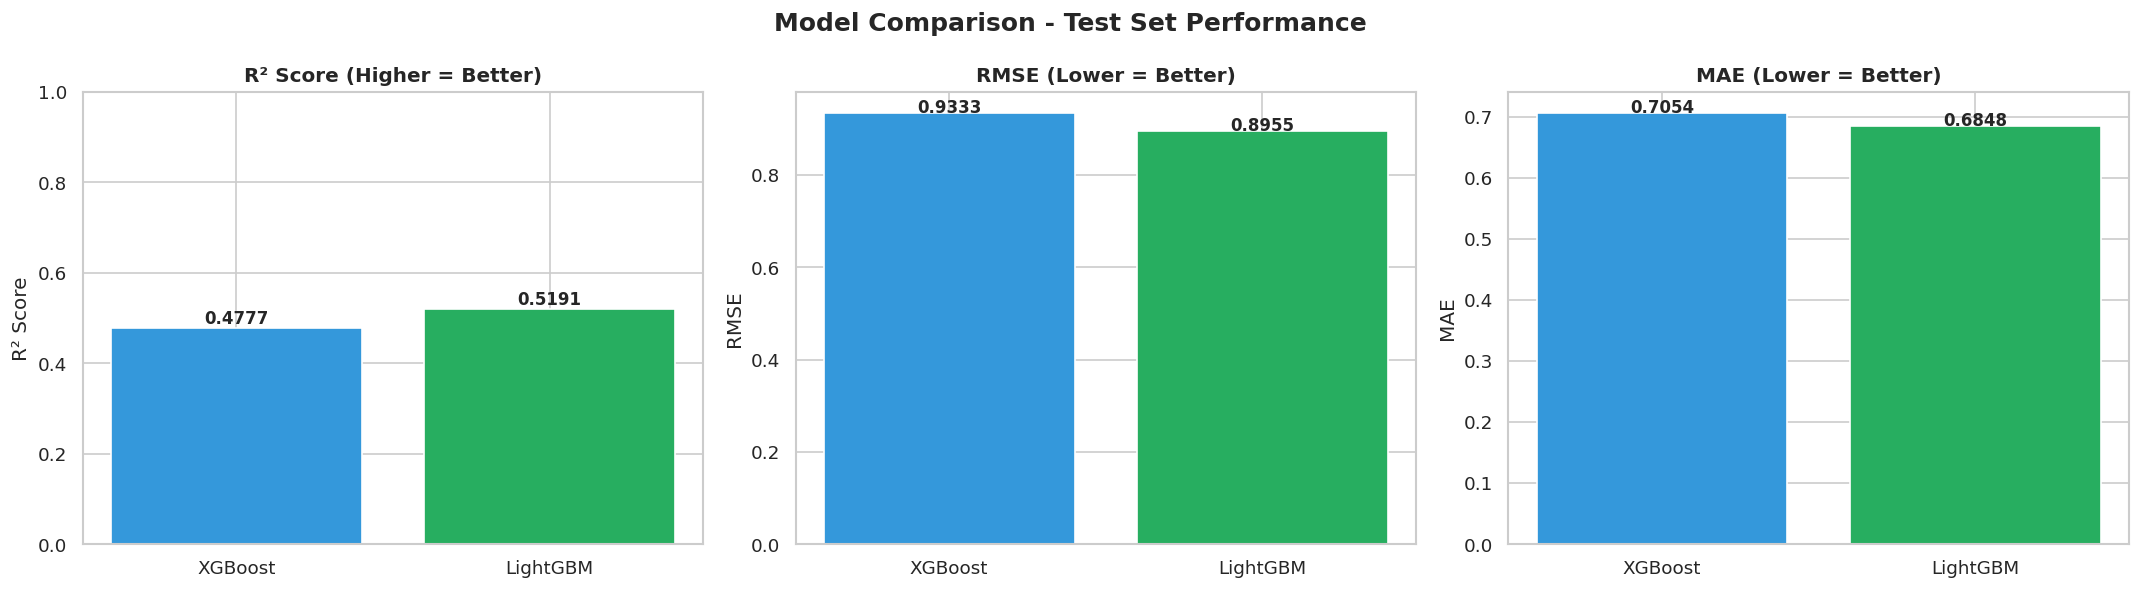


Best Model: LightGBM
Model comparison complete!


In [ ]:
# FINAL MODEL COMPARISON
print("        FINAL MODEL COMPARISON REPORT")
print("        Target: CLV_log (log of future 2011 spending)")
print(f"\n{'Model':<22} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>10} {'Test MAE':>10}")
print(f"{'XGBoost':<22} {xgb_train_r2:>10.4f} {xgb_test_r2:>10.4f} {xgb_test_rmse:>10.4f} {xgb_test_mae:>10.4f}")
print(f"{'LightGBM':<22} {lgb_train_r2:>10.4f} {lgb_test_r2:>10.4f} {lgb_test_rmse:>10.4f} {lgb_test_mae:>10.4f}")

# Bar chart comparison
models    = ['XGBoost', 'LightGBM']
r2_scores = [xgb_test_r2, lgb_test_r2]
rmse_vals = [xgb_test_rmse, lgb_test_rmse]
mae_vals  = [xgb_test_mae,  lgb_test_mae]
colors_m  = ['#3498db', '#27ae60']
#colors_m = ["steelblue", "orange"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison - Test Set Performance', fontsize=15, fontweight='bold')

axes[0].bar(models, r2_scores, color=colors_m, edgecolor='white')
axes[0].set_title('R² Score (Higher = Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score'); axes[0].set_ylim([0, 1])
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(models, rmse_vals, color=colors_m, edgecolor='white')
axes[1].set_title('RMSE (Lower = Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(models, mae_vals, color=colors_m, edgecolor='white')
axes[2].set_title('MAE (Lower = Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAE')
for i, v in enumerate(mae_vals):
    axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

if lgb_test_r2 > xgb_test_r2:
    print("\nBest Model: LightGBM")
else:
    print("\nBest Model: XGBoost")
#--------------------------------------

print("Model comparison complete!")

In [ ]:
# Customer CLV Prediction Table

# Get predictions from LightGBM
predicted_log = lgb_model.predict(X_test_scaled)

# Convert predictions back to £
predicted_clv = np.expm1(predicted_log)

# Create a simple table
prediction_table = pd.DataFrame({
    'Customer ID': customer_df.loc[X_test.index, 'Customer ID'],
    'Past Monetary (£)': customer_df.loc[X_test.index, 'Monetary'],
    'Actual Future CLV (£)': np.expm1(y_test),
    'Predicted Future CLV (£)': predicted_clv})

# Calculate prediction error
prediction_table['Error (£)'] = ( prediction_table['Actual Future CLV (£)'] - prediction_table['Predicted Future CLV (£)'])

# Round the numbers
prediction_table = prediction_table.round(2)

# Show first 10 customers
prediction_table.head(20)

,Customer ID,Past Monetary (£),Actual Future CLV (£),Predicted Future CLV (£),Error (£)
2442,17718.0,299.83,139.35,367.25,-227.90
1134,14871.0,847.84,380.33,488.02,-107.69
1510,15714.0,453.93,330.03,291.15,38.88
506,13509.0,135.00,979.72,321.95,657.77
211,12842.0,799.00,1118.99,487.81,631.18
170,12733.0,2040.92,383.95,1038.76,-654.81
433,13327.0,6251.71,2882.77,4643.34,-1760.57
270,12982.0,2354.27,390.54,1913.39,-1522.85
443,13368.0,498.10,623.40,383.71,239.69
650,13817.0,128.70,254.28,357.98,-103.70


# K-Means Clustering

##Elbow Method & silhouette score

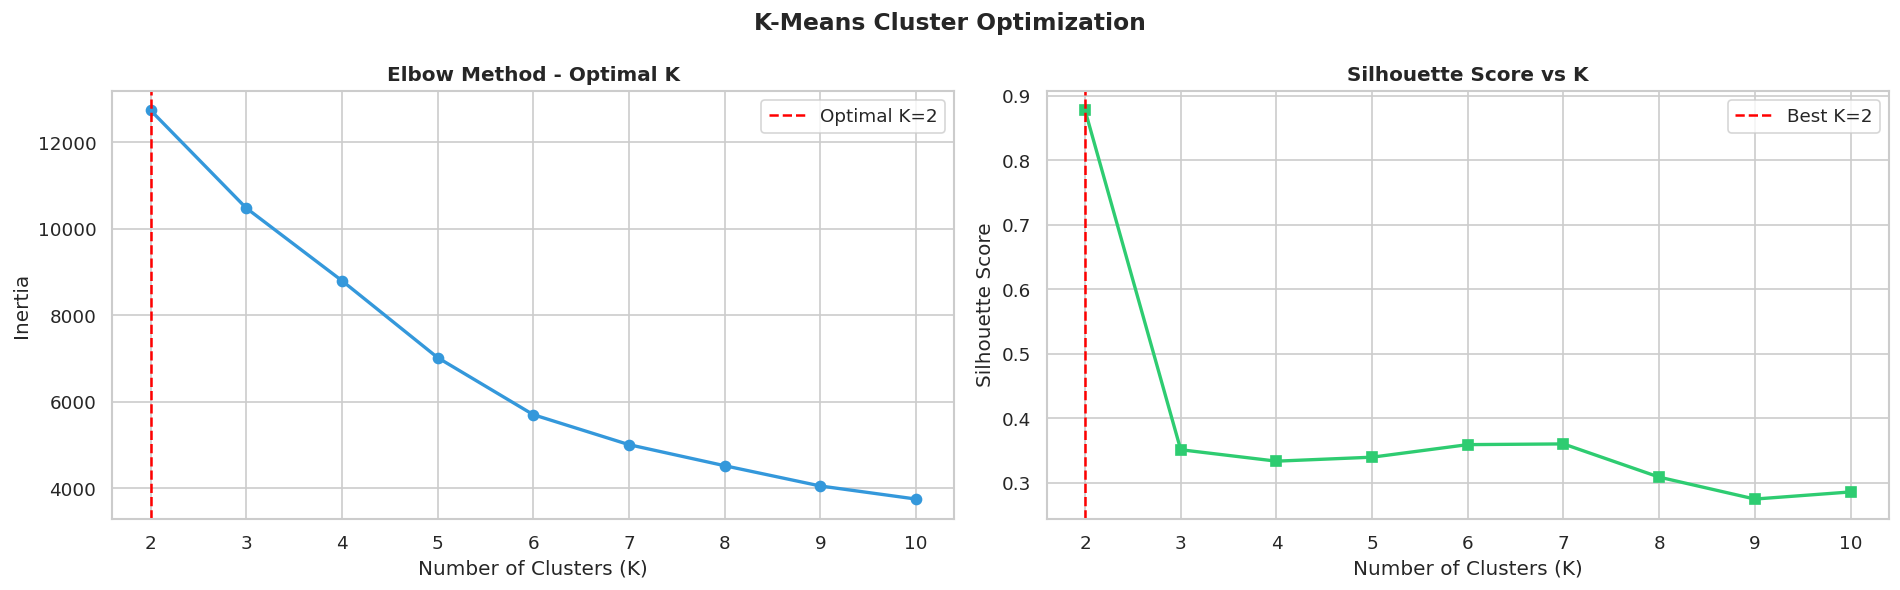

 K-Means clustering done with K=2  (auto-selected)
   Silhouette Score : 0.8778

 Customers per Cluster:
Cluster
0    2672
1      11
Name: count, dtype: int64

 Segment Labels: {1: ' High-Value', 0: ' Medium-Value'}


In [ ]:
# K-MEANS — DYNAMIC OPTIMAL K
cluster_features = ['Recency', 'Frequency', 'Monetary',
                    'ProductDiversity', 'AvgPurchaseInterval', 'AvgBasketSize']

cluster_data = customer_df[cluster_features].copy()
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

inertia_values, silhouette_values = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('K-Means Cluster Optimization', fontsize=14, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertia_values, 'o-', color='#3498db', linewidth=2)
axes[0].set_title('Elbow Method - Optimal K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette
axes[1].plot(K_range, silhouette_values, 's-', color='#2ecc71', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

best_k_idx = silhouette_values.index(max(silhouette_values))
OPTIMAL_K = list(K_range)[best_k_idx]   # ← Dynamic, not hardcoded!

axes[0].axvline(OPTIMAL_K, color='red', linestyle='--', linewidth=1.5, label=f'Optimal K={OPTIMAL_K}')
axes[1].axvline(OPTIMAL_K, color='red', linestyle='--', linewidth=1.5, label=f'Best K={OPTIMAL_K}')
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_optimization.png', bbox_inches='tight')
plt.show()

# Final K-Means
final_km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
customer_df['Cluster'] = final_km.fit_predict(cluster_scaled)

sil_score = silhouette_score(cluster_scaled, customer_df['Cluster'])
print(f" K-Means clustering done with K={OPTIMAL_K}  (auto-selected)")
print(f"   Silhouette Score : {sil_score:.4f}")
print(f"\n Customers per Cluster:\n{customer_df['Cluster'].value_counts().sort_index()}")

# Label clusters by CLV
cluster_clv = customer_df.groupby('Cluster')['CLV'].mean().sort_values(ascending=False)
label_map = {}
labels = [' High-Value', ' Medium-Value', ' At-Risk', ' Low-Value']
for i, (cluster_id, _) in enumerate(cluster_clv.items()):
    label_map[cluster_id] = labels[i]

customer_df['Segment'] = customer_df['Cluster'].map(label_map)
print(f"\n Segment Labels: {label_map}")

## Segmentation Visualisation

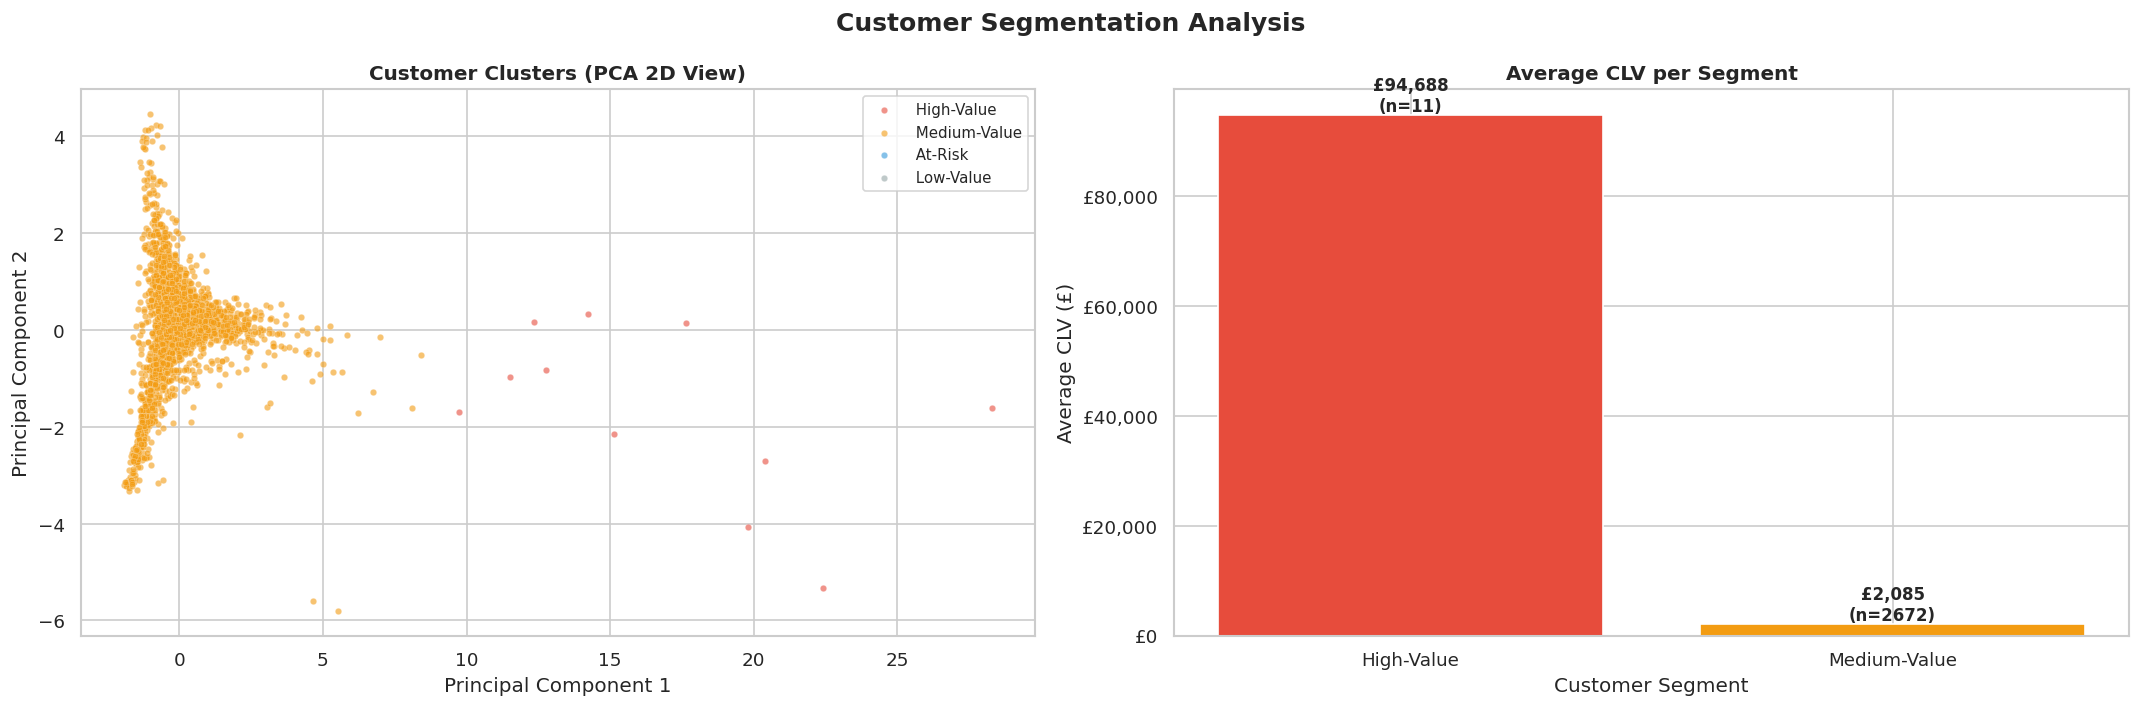

In [ ]:
#  SEGMENTATION VISUALISATION
from sklearn.decomposition import PCA

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(cluster_scaled)

customer_df['PCA1'] = pca_coords[:, 0]
customer_df['PCA2'] = pca_coords[:, 1]

# Use the actual segment labels and map them to desired colors
# The label_map from the previous cell is {1: ' High-Value', 0: 'Medium-Value'}
# We will assign colors based on the typical hierarchy (High, Medium, etc.)

segment_colors = {
    ' High-Value':   '#e74c3c',  # Red for high-value
    ' Medium-Value': '#f39c12',  # Orange for medium-value
    ' At-Risk':      '#3498db',  # Blue for at-risk
    ' Low-Value':    '#95a5a6'   # Gray for low-value
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Customer Segmentation Analysis', fontsize=15, fontweight='bold')

# PCA Scatter
for seg, color in segment_colors.items():
    mask = customer_df['Segment'] == seg
    axes[0].scatter(customer_df.loc[mask, 'PCA1'],customer_df.loc[mask, 'PCA2'],
                    c=color, label=seg, alpha=0.6, s=15, edgecolors='white', linewidth=0.2)
axes[0].set_title('Customer Clusters (PCA 2D View)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(fontsize=9)

# Segment CLV Comparison
segment_summary = customer_df.groupby('Segment').agg(Avg_CLV=('CLV', 'mean'),Customers=('CLV', 'count')).sort_values('Avg_CLV', ascending=False)

bars = axes[1].bar(
    [s.strip() for s in segment_summary.index],
    segment_summary['Avg_CLV'],
    color=[segment_colors[s] for s in segment_summary.index]
)
axes[1].set_title('Average CLV per Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Average CLV (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('segmentation_visualization.png', bbox_inches='tight')
#plt.show()

# --------------------------
# Add Average CLV + Customer Count
# --------------------------

for bar, avg_clv, count in zip(
        bars,
        segment_summary['Avg_CLV'],
        segment_summary['Customers']):

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"£{avg_clv:,.0f}\n(n={count})",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("Customer_Segmentation_Analysis.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

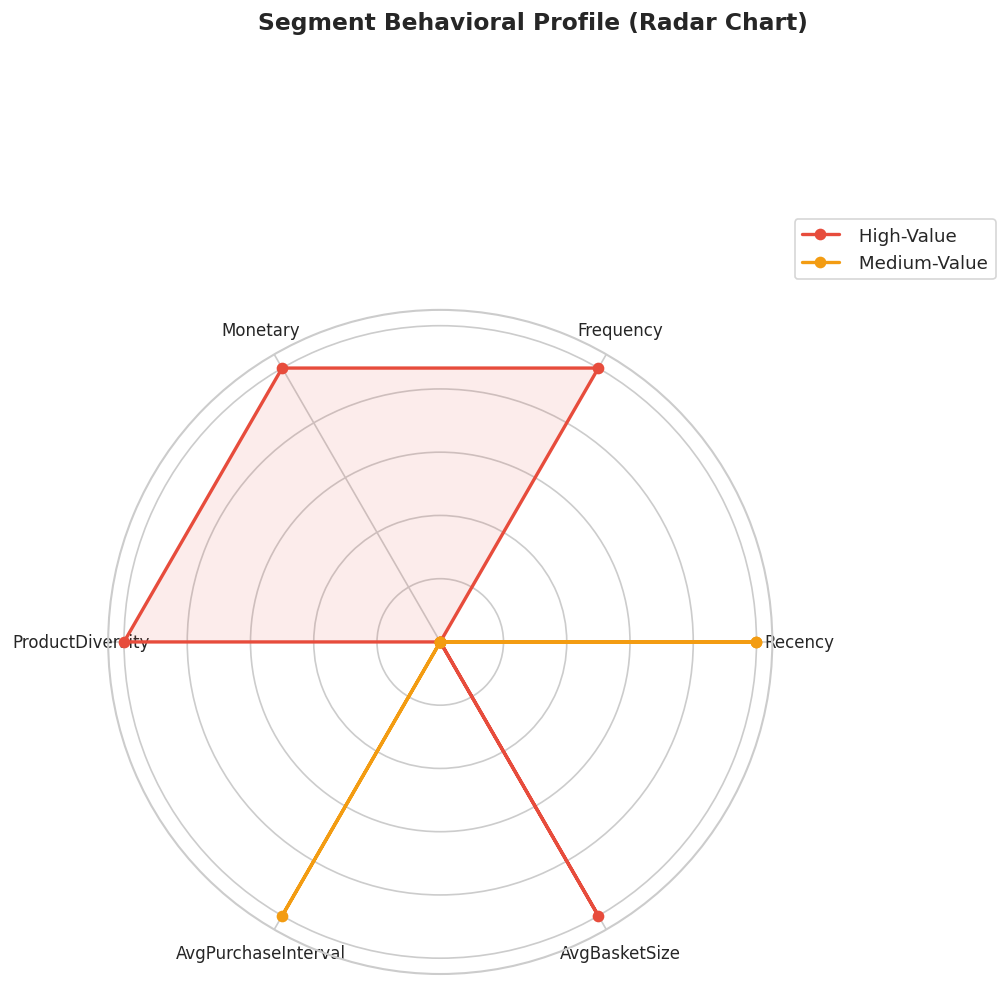

 Segmentation visualization complete!


In [ ]:
# Radar Chart: Segment Profile
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

seg_profile = customer_df.groupby('Segment')[cluster_features].mean()
seg_profile_norm = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())

categories = cluster_features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle('Segment Behavioral Profile (Radar Chart)', fontsize=14, fontweight='bold', y=1.01)

for seg, color in segment_colors.items():
    if seg in seg_profile_norm.index:
        values = seg_profile_norm.loc[seg].values.tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=seg)
        ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticklabels([])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight')
plt.show()

print(" Segmentation visualization complete!")

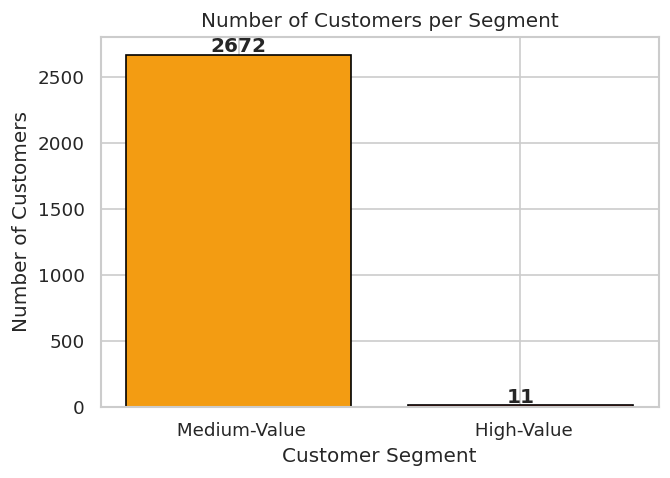

In [ ]:
# Number of customers in each segment
segment_counts = customer_df['Segment'].value_counts()

plt.figure(figsize=(6,4))

colors = [segment_colors[s] for s in segment_counts.index]

plt.bar(segment_counts.index,
        segment_counts.values,
        color=colors,
        edgecolor='black')

plt.title("Number of Customers per Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.show()

In [ ]:
high_value_customers = customer_df[
    customer_df['Segment'].str.strip() == 'High-Value'
]

high_value_customers[
    ['Customer ID', 'Recency', 'Frequency',
     'Monetary', 'CLV', 'Segment']
]

,Customer ID,Recency,Frequency,Monetary,CLV,Segment
174,12748.0,1,162,24671.45,28868.19,High-Value
320,13089.0,8,114,60608.04,52808.87,High-Value
591,13694.0,7,95,133498.11,62142.58,High-Value
794,14156.0,21,102,196549.74,116887.88,High-Value
1006,14606.0,2,107,19108.98,10842.39,High-Value
1025,14646.0,3,80,256988.38,271614.14,High-Value
1154,14911.0,1,210,155447.58,135973.23,High-Value
1222,15061.0,9,91,91805.54,34583.48,High-Value
1340,15311.0,1,126,56993.68,57972.74,High-Value
2490,17841.0,5,93,30493.53,38051.72,High-Value


In [ ]:
medium_value_customers = customer_df[
    customer_df['Segment'].str.strip() == 'Medium-Value'
]

medium_value_customers[
    ['Customer ID', 'Recency', 'Frequency',
     'Monetary', 'CLV', 'Segment']
]

,Customer ID,Recency,Frequency,Monetary,CLV,Segment
0,12346.0,179,11,372.86,77183.60,Medium-Value
1,12347.0,17,2,1323.32,3598.21,Medium-Value
2,12348.0,7,2,1114.96,904.44,Medium-Value
3,12349.0,57,3,2671.14,1757.55,Medium-Value
4,12352.0,25,2,343.80,2506.04,Medium-Value
...,...,...,...,...,...,...
2678,18278.0,54,1,240.30,173.90,Medium-Value
2679,18280.0,44,1,307.55,180.60,Medium-Value
2680,18281.0,227,1,120.32,80.82,Medium-Value
2681,18283.0,32,6,619.37,2045.53,Medium-Value


# CLV Prediction + Strategic Customer Segmentation

In [ ]:
import pandas as pd

# FINAL SUMMARY REPORT
print("    FINAL PROJECT SUMMARY REPORT")
print("   CLV Prediction + Strategic Customer Segmentation")

print("\n DATASET OVERVIEW")
print(f"   Total Customers Analyzed : {len(customer_df):,}")
print(f"   Total Transactions Used  : {len(df):,}")
print(f"   Date Range               : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

print("\n CLV PREDICTION (LGB)")
print(f"   Train R²    : {lgb_train_r2:.4f}")
print(f"   Test  R²    : {lgb_test_r2:.4f}")
print(f"   Train RMSE    :{lgb_train_rmse:.4f}")
print(f"   Test  RMSE  : {lgb_test_rmse:.4f}")
print(f"   Train MAE   : {lgb_train_mae:.4f}")
print(f"   Test  MAE   : {lgb_test_mae:.4f}")
print(f"   CV R² Mean  : {cv_scores_lgb.mean():.4f} ± {cv_scores_lgb.std():.4f}")

print("\n CUSTOMER SEGMENTATION (K-Means)")
print(f"   Optimal K             : {OPTIMAL_K}")
print(f"   Silhouette Score      : {sil_score:.4f}")
print(f"\n   {'Segment':<22} {'Count':>8} {'Avg CLV':>12}")
print("   " + "-" * 44)
for seg in customer_df['Segment'].unique():
    seg_data = customer_df[customer_df['Segment'] == seg]
    print(f"   {seg:<22} {len(seg_data):>8,} {seg_data['CLV'].mean():>12,.2f}")

print("\n TOP FEATURES FOR CLV PREDICTION")
top_feats = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, score in top_feats.items():
    bar =  int(score * 100)
    print(f"   {feat:<22} {score:.4f}  {bar}")


print("Analysis Complete — All objectives satisfied!")

    FINAL PROJECT SUMMARY REPORT
   CLV Prediction + Strategic Customer Segmentation

 DATASET OVERVIEW
   Total Customers Analyzed : 2,683
   Total Transactions Used  : 779,425
   Date Range               : 2009-12-01 → 2011-12-09

 CLV PREDICTION (LGB)
   Train R²    : 0.6798
   Test  R²    : 0.5191
   Train RMSE    :0.7271
   Test  RMSE  : 0.8955
   Train MAE   : 0.5634
   Test  MAE   : 0.6848
   CV R² Mean  : 0.4894 ± 0.0695

 CUSTOMER SEGMENTATION (K-Means)
   Optimal K             : 2
   Silhouette Score      : 0.8778

   Segment                   Count      Avg CLV
   --------------------------------------------
    Medium-Value             2,672     2,085.32
    High-Value                  11    94,687.99

 TOP FEATURES FOR CLV PREDICTION
   Monetary               393.0000  39300
   AvgBasketSize          333.0000  33300
   AvgUnitPrice           294.0000  29400
   Recency                258.0000  25800
   AvgPurchaseInterval    227.0000  22700
   ProductDiversity       209.000